# Progression constraints from cross-sectional data with MHN

A cross-sectional cohort tells you *which* alterations a patient carries, never the order they
arrived in. **[MHN](https://github.com/spang-lab/LearnMHN)** (Mutual Hazard Networks, Schill et al.
2020) is built for exactly that: it fits a network of promoting and inhibiting effects between events
from a binary patients × events matrix — the shape a bulk or panel-sequencing cohort actually has.

This runs the real `mhn` package **in this notebook's own kernel** (`Python (iscc-mhn)`), so the
fitted model is here to inspect and its own plotting works.

| file | what it is | who sees it |
|---|---|---|
| `X_presence.csv` | patients × events, binary | the tool |
| `X_presence_control.csv` | the same simulation with the constraints removed | the tool |
| `truth_network.json` | the planted precedence DAG | **scoring only** |

Generated by `python validation/make_analysis_data.py --only mhn`; the planted network is laid out in
[The analysis dataset and its ground truth](analysis_ground_truth.ipynb).

**Why there is a control arm.** A regularised network model fitted to a few hundred patients will
always report *something*. The only way to know whether an edge means anything is to run the identical
pipeline on a cohort grown the same way with the constraints removed, and see what it reports there.

In [1]:
import json, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from mhn.optimizers import cMHNOptimizer

DATA = os.path.join("..", "analysis_data", "mhn")
assert os.path.isdir(DATA), (
    f"dataset not found at {DATA}\n"
    "  generate it first:  python validation/make_analysis_data.py --only mhn")

X     = pd.read_csv(os.path.join(DATA, "X_presence.csv"), index_col=0)
Xctl  = pd.read_csv(os.path.join(DATA, "X_presence_control.csv"), index_col=0)
truth = json.load(open(os.path.join(DATA, "truth_network.json")))
meta  = json.load(open(os.path.join(DATA, "meta.json")))
dag, events = truth["true_dag_edges"], list(X.columns)

print(f"cohort: {X.shape[0]} patients, {X.shape[1]} events   (control arm: {Xctl.shape[0]})")
print(f"gating: {truth['dependency_params']['gating_mode']}   "
      f"planted precedence constraints: {len(dag)}")
for p, c in dag:
    print(f"   {events[p]}  must precede  {events[c]}")
print("\nevent presence  ", X.mean(axis=0).round(2).to_dict())
print("control          ", Xctl.mean(axis=0).round(2).to_dict())

/Users/pedroferreira/miniconda3/envs/iscc-mhn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cohort: 295 patients, 4 events   (control arm: 295)
gating: accessibility   planted precedence constraints: 2
   E3  must precede  E2
   E0  must precede  E1

event presence   {'E0': 0.78, 'E1': 0.06, 'E2': 0.25, 'E3': 0.83}
control           {'E0': 0.8, 'E1': 0.63, 'E2': 0.94, 'E3': 0.64}


## What makes this cohort readable, and why it is not TreeMHN's

Both benchmarks are scored on the *same kind* of truth — an **accessibility**-gated DAG, meaning the
constraint acts on the mutation process itself, so a child genuinely cannot arise before its parent.
That is a hard zero in the joint distribution, `P(child ∧ ¬parent) = 0`, and reading it is precisely
what MHN does.

They cannot share a cohort, though, and the reason is worth stating because it is a property of the
*data*, not of either method. [TreeMHN's cohort](tool_treemhn_R.ipynb) is grown long enough, with a
common enough event alphabet, that the gated children leave an ordering trace in tree topology. The
price is that every event then turns up somewhere in every patient: all four sit at presence 1.00, so
every column is constant and **nothing is identifiable** — MHN's Θ collapses to zero at every
penalty. A detection floor does not rescue it either, because those events are common but
*subclonal*.

Stopping the cohort earlier fixes it. The parents here sit short of fixation, which is the entire
requirement: a column present in every patient carries no information about anything.

One other thing iscc's fitness epistasis does **not** give MHN: `E` changes how large the clones
carrying a combination grow, not how often it arises, so it leaves the binary columns untouched. That
signal lives in clone frequency, and it is not what a presence/absence method reads.

In [2]:
def fit(M, lam):
    opt = cMHNOptimizer()
    opt.load_data_matrix(M.astype(np.int32))       # a DataFrame, so the model keeps the event names
    return opt.train(lam=lam, maxit=5000)

# MHN is regularised and the penalty decides everything: too strong and every entry shrinks to zero.
# The package prescribes cross-validation, with two settings that matter here.
#
#   The SEARCH RANGE has to be given. On the default range the optimum lands on the ceiling and the
#   whole network is shrunk away -- lambda_from_cv warns when it does.
#
#   The folds are SHUFFLED, so the chosen lambda moves between runs; np.random.seed fixes them (the
#   package's own docstring says to). The stability check below reports what that costs.
np.random.seed(0)
opt = cMHNOptimizer(); opt.load_data_matrix(X.astype(np.int32))
lam = opt.lambda_from_cv(lambda_min=1e-4, lambda_max=0.05, nfolds=5, show_progressbar=False)

model     = fit(X, lam)
model_ctl = fit(Xctl, lam)                          # identical pipeline, identical penalty
print(f"lambda chosen by 5-fold CV over [1e-4, 0.05]: {lam:.5f}")
print(f"fitted {type(model).__name__} over events {model.events}")

lambda chosen by 5-fold CV over [1e-4, 0.05]: 0.00486
fitted cMHN over events ['E0', 'E1', 'E2', 'E3']


## MHN's own figure: the Θ matrix

`plot()` is the package's own figure. The **diagonal** holds each event's baseline rate; an
**off-diagonal** `Θ[i, j]` is the multiplicative effect of event *j* on the rate of event *i* — red
promotes, blue inhibits. A planted "*p* must precede *c*" should surface as a large positive entry in
**row *c*, column *p***.

The control is drawn beside it on the same scale. Whatever appears there is what this pipeline
produces from a cohort with no constraints in it at all.

/Users/pedroferreira/miniconda3/envs/iscc-mhn/lib/python3.11/site-packages/mhn/model.py:602: UserWarning: Provided axes object is not 3-dimensional, creating new axes object
  warnings.warn(
/Users/pedroferreira/miniconda3/envs/iscc-mhn/lib/python3.11/site-packages/mhn/model.py:602: UserWarning: Provided axes object is not 3-dimensional, creating new axes object
  warnings.warn(


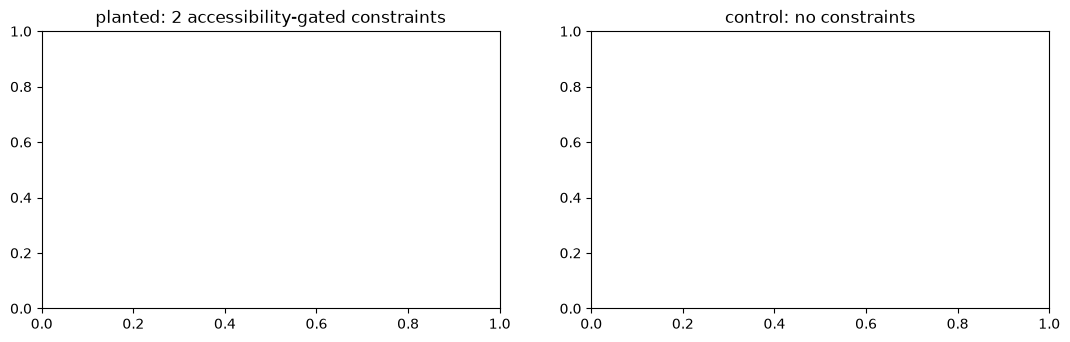

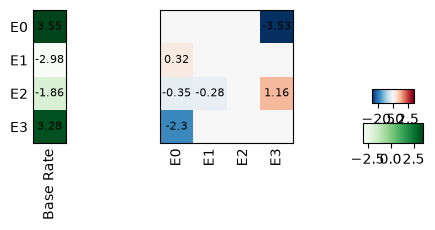

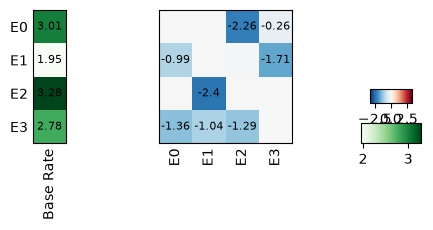

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
model.plot(ax=axes[0], annot=0.1)
axes[0].set_title(f"planted: {len(dag)} accessibility-gated constraints")
model_ctl.plot(ax=axes[1], annot=0.1)
axes[1].set_title("control: no constraints")
plt.show()

## Scoring against the planted constraints

The question is not whether Θ looks plausible — it is whether the planted pairs are the *top-ranked*
promoting entries out of every off-diagonal, and whether the control leaves them alone.

In [4]:
def ranks(m):
    T = np.asarray(m.log_theta)
    n = T.shape[0]
    off = [(i, j) for i in range(n) for j in range(n) if i != j]
    order = sorted(off, key=lambda ij: -T[ij])
    return [(order.index((c, p)) + 1, T[c, p]) for p, c in dag], len(off)

(r_planted, n_off), (r_ctl, _) = ranks(model), ranks(model_ctl)

print(f"rank among {n_off} off-diagonal entries (1 = strongest promoting effect)\n")
print(f"  {'constraint':<16}{'child in':>10}{'planted cohort':>28}{'control':>24}")
for (p, c), (rp, vp), (rc, vc) in zip(dag, r_planted, r_ctl):
    print(f"  {events[p]} -> {events[c]:<11}"
          f"{X[events[c]].mean():>9.0%}"
          f"{f'rank {rp} of {n_off}   Theta {vp:+.2f}':>28}"
          f"{f'rank {rc}   Theta {vc:+.2f}':>24}")

rank among 12 off-diagonal entries (1 = strongest promoting effect)

  constraint        child in              planted cohort                 control
  E3 -> E2               25%  rank 1 of 12   Theta +1.16    rank 3   Theta -0.00
  E0 -> E1                6%  rank 2 of 12   Theta +0.32    rank 6   Theta -0.99


### How much of that depends on the penalty

One fit at one λ is not a result. The CV shuffles its folds, so re-seeding it lands on a different λ
— the check below refits at each and reports where the planted constraints come out.

In [5]:
print(f"{'CV seed':>8}{'lambda':>10}   " + "   ".join(f"{events[p]}->{events[c]}" for p, c in dag))
for sd in range(5):
    np.random.seed(sd)
    o = cMHNOptimizer(); o.load_data_matrix(X.astype(np.int32))
    l = o.lambda_from_cv(lambda_min=1e-4, lambda_max=0.05, nfolds=5, show_progressbar=False)
    rs, _ = ranks(fit(X, l))
    print(f"{sd:>8}{l:>10.5f}   " + "   ".join(f"rank {r:<2} ({v:+.2f})" for r, v in rs))

 CV seed    lambda   E3->E2   E0->E1


       0   0.00486   rank 1  (+1.16)   rank 2  (+0.32)


       1   0.01057   rank 1  (+0.13)   rank 4  (+0.00)


       2   0.01057   rank 1  (+0.13)   rank 4  (+0.00)


       3   0.01057   rank 1  (+0.13)   rank 4  (+0.00)


       4   0.00486   rank 1  (+1.16)   rank 2  (+0.32)


**What that says.** `E3 → E2` comes out as the **strongest promoting entry of all twelve at every λ
the CV selects**, and the control never reports it. That constraint is recovered.

`E0 → E1` is at the edge of what this cohort can support, and the reason is printed in the table
above rather than hidden: **E1 is carried by only ~6% of patients**. Roughly eighteen people in the
cohort have the event whose ordering is in question, so how strongly it shows depends on the penalty.
Its sign is right and the control puts it firmly negative, but this is a power limit, not a recovery.

That limit is not fixable by adding patients — more of them makes E1 *rarer*, because a longer-tailed
cohort dilutes it — nor by re-drawing the network, which was checked across eight draws. With four
events and a gated child this rare, one of the two constraints is estimable from presence alone and
the other is not. Knowing which is which is only possible because the answer key exists.

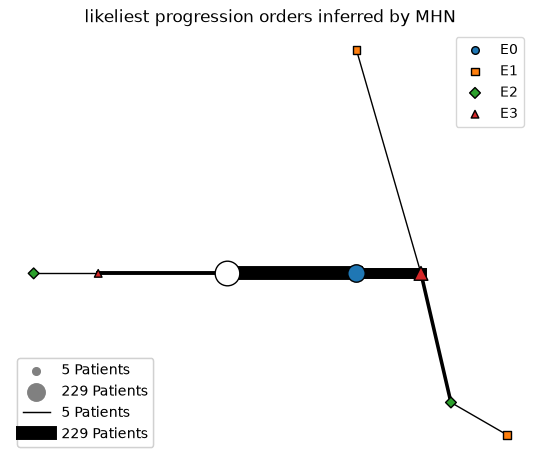

In [6]:
fig, ax = plt.subplots(figsize=(7, 5.5))
model.plot_order_tree(states=X.values.astype(np.int32), ax=ax,
                      min_number_of_occurrence=5, legend=True)
ax.set_title("likeliest progression orders inferred by MHN")
plt.show()

## What to take from it

MHN fits `iscc` cohorts in the shape real cross-sectional data comes in, recovers the planted
precedence constraints as the strongest promoting effects in the network, and reports neither of them
on a control cohort grown identically without them.

The comparison worth making is with [the same kind of truth read as trees](tool_treemhn_R.ipynb).
TreeMHN sees the order in which each patient acquired its events; MHN sees only the endpoint, and has
to infer order from which combinations never occur. Both work — on cohorts that suit them, which are
not the same cohort. That is a statement about **observables**, and `iscc` can make it because it can
grow the same constraint into two different kinds of data and hold both against the answer key.